# Channel arm: Selected vs. All markers (Max-Projection)

Does giving a model every marker (zero-padded) instead of the curated panel change segmentation quality?
Max-Projection only, 6 models x 4 datasets x 5 folds. Scores come from `results/all_runs.csv`
(`validation/consolidate.py`).

In [1]:
import sys
from pathlib import Path

BENCH_DIR = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if p.name == "bench")
sys.path.insert(0, str(BENCH_DIR))

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_rel

from validation.consolidate import DATASETS, N_FOLDS, load
from figures.utils import holm_adjust, stars

matplotlib.rcParams["pdf.fonttype"] = 42
EXPORT_DIR = BENCH_DIR / "figures" / "export"

METRIC = "PQ"
MODEL_ORDER = ["Cellpose", "InstanSeg", "Stardist", "Dist U-Net", "Cellpose-SAM", "MicroSAM"]
ARMS = ["selected", "all"]
ARM_LABELS = {"selected": "Selected (curated)", "all": "All markers"}
PALETTE = {"selected": "#4C72B0", "all": "#DD8452"}

## Load

In [2]:
scores = load()  # one row per test image of every run
scores = scores[(scores["Modality"] == "MaxProj") & scores["Model"].isin(MODEL_ORDER) & scores["Arm"].isin(ARMS)]

# Mean score per fold: one value per (model, dataset, arm, fold)
fold_means = scores.groupby(["Model", "Dataset", "Arm", "Fold"], as_index=False)[METRIC].mean()

assert len(fold_means) == len(MODEL_ORDER) * len(DATASETS) * len(ARMS) * N_FOLDS, "some runs are missing"
fold_means.head()

,Model,Dataset,Arm,Fold,PQ
0,Cellpose,CODEX,all,0,0.542996
1,Cellpose,CODEX,all,1,0.560520
2,Cellpose,CODEX,all,2,0.537771
3,Cellpose,CODEX,all,3,0.544843
4,Cellpose,CODEX,all,4,0.548741


## Bars per model

Each bar is the mean over 20 points (4 datasets x 5 folds), error bars are the SD.

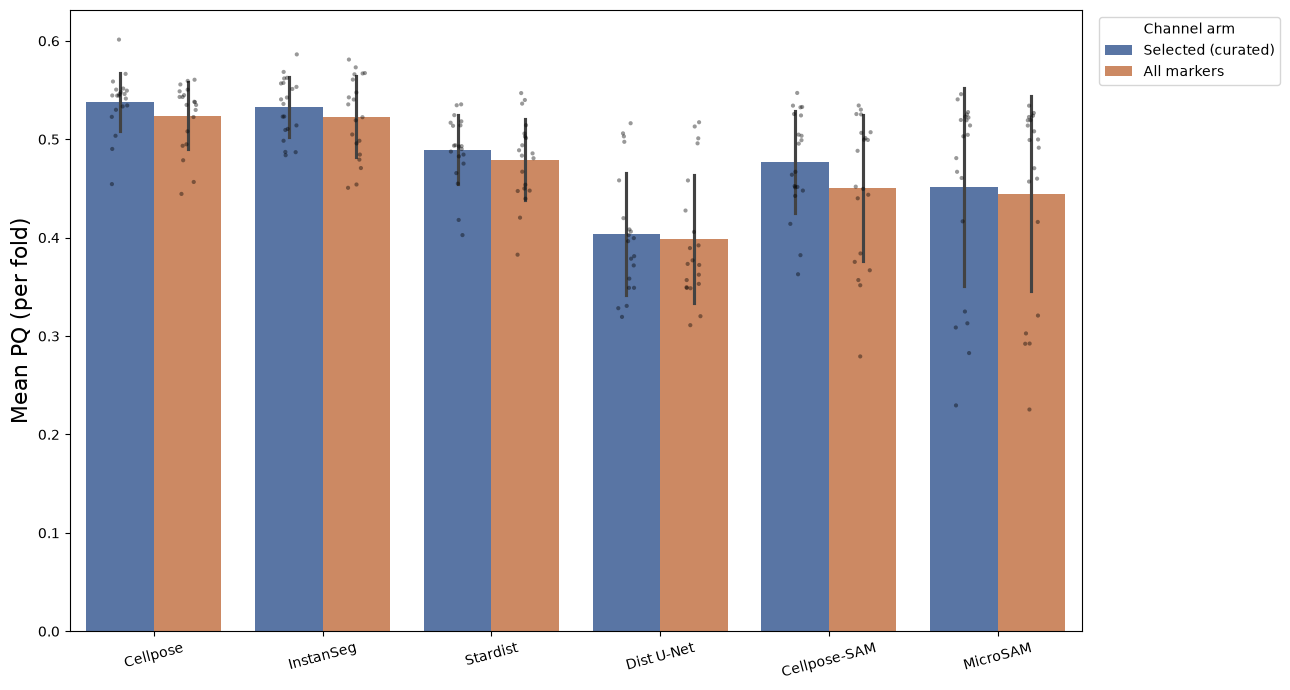

In [3]:
fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(
    data=fold_means, x="Model", y=METRIC, hue="Arm",
    order=MODEL_ORDER, hue_order=ARMS, palette=PALETTE, errorbar="sd", ax=ax,
)
sns.stripplot(
    data=fold_means, x="Model", y=METRIC, hue="Arm",
    order=MODEL_ORDER, hue_order=ARMS, dodge=True,
    palette=["black", "black"], alpha=0.4, size=3, ax=ax, legend=False,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [ARM_LABELS[l] for l in labels], title="Channel arm",
          loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_xlabel("")
ax.set_ylabel(f"Mean {METRIC} (per fold)", fontsize=16)
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "ChannelArm_Overall_PQ.pdf", bbox_inches="tight")

## Significance per model

Paired t-test, All vs. Selected, paired by (dataset, fold), so 20 pairs per model.
Holm correction across the 6 models.

In [4]:
rows = []
for model in MODEL_ORDER:
    wide = fold_means[fold_means["Model"] == model].pivot(index=["Dataset", "Fold"], columns="Arm", values=METRIC)
    _, p = ttest_rel(wide["all"], wide["selected"])
    rows.append({
        "Model": model,
        "n_pairs": len(wide),
        "mean_diff (all - selected)": (wide["all"] - wide["selected"]).mean(),
        "p_raw": p,
    })

significance = pd.DataFrame(rows)
significance["p_holm"] = holm_adjust(significance["p_raw"])
significance["stars"] = significance["p_holm"].apply(stars)
significance

,Model,n_pairs,mean_diff (all - selected),p_raw,p_holm,stars
0,Cellpose,20,-0.014070,0.017980,0.089899,ns
1,InstanSeg,20,-0.009593,0.051748,0.172220,ns
2,Stardist,20,-0.010156,0.061633,0.172220,ns
3,Dist U-Net,20,-0.005351,0.213805,0.213805,ns
4,Cellpose-SAM,20,-0.025916,0.003881,0.023286,*
5,MicroSAM,20,-0.006654,0.043055,0.172220,ns


## Per-image distributions by dataset

Same comparison, but every test image is a point instead of a fold mean. Diamonds mark the mean.

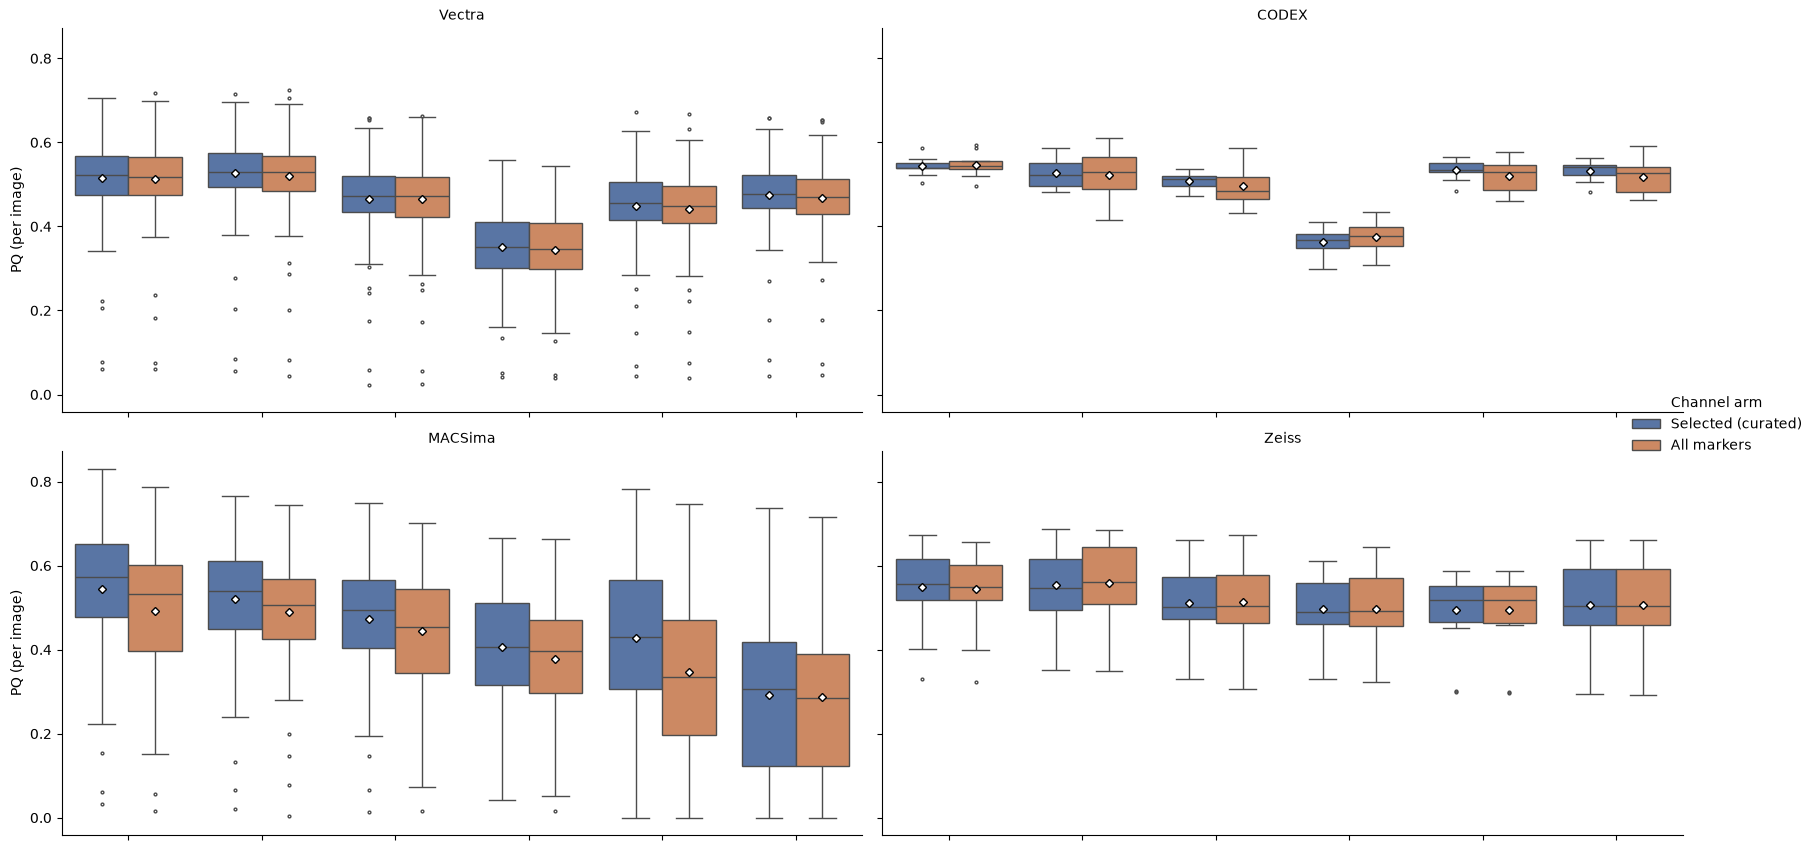

In [5]:
g = sns.catplot(
    data=scores, kind="box", x="Model", y=METRIC, hue="Arm", col="Dataset",
    order=MODEL_ORDER, hue_order=ARMS, col_order=DATASETS, col_wrap=2, palette=PALETTE,
    showmeans=True, meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=4),
    fliersize=2, height=4.5, aspect=1.9,
)
g.set_titles("{col_name}")
g.set_axis_labels("", f"{METRIC} (per image)")
g.set_xticklabels(rotation=20)
for text in g.legend.texts:
    text.set_text(ARM_LABELS[text.get_text()])
g.legend.set_title("Channel arm")
g.savefig(EXPORT_DIR / "ChannelArm_ByDataset_PQ.pdf", bbox_inches="tight")